<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->

# ArrayWUnits and ArrayWFrame
---
*Last revised 2026*

This tutorial introduces the two core data containers that flow through every
Scarabaeus workflow:

- `ArrayWUnits`: Numerical array **+** physical units (km, km/s, ...)
- `ArrayWFrame`: Numerical array **+** units **+** reference frame (J2000, ITRF93, ...)

**Contents**

1. Dimensions and Units — `Units`, `Dimensions`
2. `ArrayWUnits` — construction, arithmetic, conversion, safety checks
3. Frames — `Frame.generate_common_frames`, DCM, full transformation
4. `ArrayWFrame` — construction, frame conversion, frame-aware arithmetic

## 0. Imports and Setup

In [1]:
import scarabaeus as scb
import supplementary as supp

import numpy as np

# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)

SCB supplementary data up to date.


## 1. Dimensions and Units

Scarabaeus tracks physical dimensions through every arithmetic operation.
`Units.get_units()` returns unit objects that carry both scale and dimension.

In [2]:
km, m, sec, day, rad, deg, kg = scb.Units.get_units(
    ['km', 'm', 'sec', 'day', 'rad', 'deg', 'kg'])

print(f"km   : {km}   dimensions → {km.dimensions}")
print(f"m    : {m}    dimensions → {m.dimensions}")
print(f"sec  : {sec}  dimensions → {sec.dimensions}")
print(f"deg  : {deg}  dimensions → {deg.dimensions}")
print(f"kg   : {kg}   dimensions → {kg.dimensions}")

km   : km   dimensions → Length
m    : m    dimensions → Length
sec  : sec  dimensions → Time
deg  : deg  dimensions → Angle
kg   : kg   dimensions → Mass


In [3]:
# Unit arithmetic propagates dimensions automatically
vel_unit   = km / sec
acc_unit   = km / sec**2
area_unit  = km**2
freq_unit  = sec**-1

print(f"km/sec     : {vel_unit}   → {vel_unit.dimensions}")
print(f"km/sec²    : {acc_unit}   → {acc_unit.dimensions}")
print(f"km²        : {area_unit}  → {area_unit.dimensions}")
print(f"sec⁻¹      : {freq_unit}  → {freq_unit.dimensions}")
print(f"km * kg    : {km * kg}    → {(km * kg).dimensions}")

km/sec     : km/sec   → Velocity
km/sec²    : km/sec^2   → Acceleration
km²        : km^2  → Area
sec⁻¹      : Hz  → per Time
km * kg    : kg*km    → Mass times Length


## 2. `ArrayWUnits`

`ArrayWUnits` wraps a NumPy array together with its physical units.
The units travel with the array through every mathematical operation.

In [4]:
# ── Scalars ──────────────────────────────────────────────────────
altitude   = scb.ArrayWUnits(408.0,   km)     # ISS altitude
period     = scb.ArrayWUnits(5552.0,  sec)    # ISS orbital period
dry_mass   = scb.ArrayWUnits(419725.0, kg)    # ISS mass

print(f"Altitude  : {altitude}")
print(f"Period    : {period}")
print(f"Mass      : {dry_mass}")
print(f"altitude.values : {altitude.values}   (raw float)")
print(f"altitude.units  : {altitude.units}")

Altitude  : 408.0 km
Period    : 5552.0 sec
Mass      : 419725.0 kg
altitude.values : 408.0   (raw float)
altitude.units  : km


In [5]:
# ── Homogeneous vector (all elements share one unit) ─────────────
pos = scb.ArrayWUnits(np.array([7000.0, -1200.0, 3500.0]), km)
vel = scb.ArrayWUnits(np.array([-1.2,     6.8,    3.1  ]), km/sec)

print("Position [km] :", pos)
print("Velocity [km/s]:", vel)
print("pos.values :", pos.values)
print("pos.shape  :", pos.shape)
print()

# ── Heterogeneous state vector (pos + vel, mixed units per element) ─
state = scb.ArrayWUnits(
    np.array([7000.0, -1200.0, 3500.0, -1.2, 6.8, 3.1]),
    [km, km, km, km/sec, km/sec, km/sec],
)
print("State vector (mixed units):")
print(f"  values : {state.values}")
print(f"  units  : {state.units}")

Position [km] : [ 7000. -1200.  3500.] [km ... km]
Velocity [km/s]: [-1.2  6.8  3.1] [km/sec ... km/sec]
pos.values : [ 7000. -1200.  3500.]
pos.shape  : (3,)

State vector (mixed units):
  values : [ 7.0e+03 -1.2e+03  3.5e+03 -1.2e+00  6.8e+00  3.1e+00]
  units  : [km km km km/sec km/sec km/sec]


In [6]:
# ── Arithmetic — units propagate automatically ────────────────────
pos1 = scb.ArrayWUnits(np.array([1000.0, 2000.0, 3000.0]), km)
pos2 = scb.ArrayWUnits(np.array([ 500.0,  800.0, 1200.0]), km)
dt   = scb.ArrayWUnits(60.0, sec)
mass = scb.ArrayWUnits(500.0, kg)

print(f"pos1 * 2     = {pos1 * 2}")
print(f"pos1 \ dt    = {pos1 / dt}")     # km/sec
print(f"(pos1/dt)**2 = {(pos1/dt)**2}")  # km²/sec²
print(f"mass * 9.8   = {mass * 9.8}")

# ── Safety: same dimensions required for + / - ───────────────────
print()
print("Adding km + km/sec (should raise TypeError):")
try:
    _ = pos1 + vel
except (ValueError, TypeError) as e:
    print(f"  Blocked: {type(e).__name__}")

pos1 * 2     = [2000. 4000. 6000.] [km ... km]
pos1 \ dt    = [16.66666667 33.33333333 50.        ] [km/sec ... km/sec]
(pos1/dt)**2 = [ 277.77777778 1111.11111111 2500.        ] [km^2/sec^2 ... km^2/sec^2]
mass * 9.8   = 4900.0 kg

Adding km + km/sec (should raise TypeError):
  Blocked: ValueError


In [7]:
# ── Unit conversion ──────────────────────────────────────────────
dist_km  = scb.ArrayWUnits(384400.0, km)       # Moon distance
dist_m   = dist_km.convert_to(m)               # → metres
dist_day_km = scb.ArrayWUnits(86400.0, sec).convert_to(day)  # 1 day in days

print(f"\nUnit conversion:")
print(f"{dist_km}  →  {dist_m}")
print(f"86400 sec  →  {dist_day_km}")


Unit conversion:
384400.0 km  →  384400000.0 m
86400 sec  →  1.0 day


## 3. Frames

A `Frame` object holds the SPICE frame name and ID.
`Frame.generate_common_frames()` returns four frames used throughout Scarabaeus.

In [8]:
J2000, ITRF93, ECLIPJ2000, IAUEARTH = scb.Frame.generate_common_frames()

for fr in [J2000, ITRF93, ECLIPJ2000, IAUEARTH]:
    print(fr)

J2000 (0 - SOLAR SYSTEM BARYCENTER)
ITRF93 (399 - EARTH)
ECLIPJ2000 (0 - SOLAR SYSTEM BARYCENTER)
IAU_EARTH (399 - EARTH)


In [9]:
J2000.disp_properties()

Frame Properties
Frame Name:     J2000
Frame ID:       1
Origin Name:    SOLAR SYSTEM BARYCENTER
Origin ID:      0
Frame Class:    1
Class ID:       1


## 4. Frame Transformations

`Frame.get_DCM` returns the 3×3 Direction Cosine Matrix (rotation only).
`Frame.get_transformation` returns the 6×6 state-transformation matrix (rotation + rate).

In [10]:
# ── Define an epoch ──────────────────────────────────────────────
et0    = scb.SpiceManager.jd2et(2461809.72995654)   # arbitrary JD
epoch  = scb.EpochArray(np.array([et0]), sys='TDB')

# ── Direction Cosine Matrix: J2000 → IAUEARTH ────────────────────
# get_DCM returns a plain numpy ndarray (shape 3×3)
R = scb.Frame.get_DCM(source_frame=J2000, target_frame=IAUEARTH, epoch=epoch)

print(f"DCM shape  : {R.shape}")
print(f"DCM (J2000→IAUEARTH):\n{np.round(R, 6)}")

# ── Verify it is orthogonal: R @ Rᵀ ≈ I ─────────────────────────
RRT = R @ R.T
print(f"\n||R @ Rᵀ − I||₂ = {np.linalg.norm(RRT - np.eye(3)):.2e}  (should be ~0)")

DCM shape  : (3, 3)
DCM (J2000→IAUEARTH):
[[-7.63801e-01 -6.45449e-01  2.08100e-03]
 [ 6.45446e-01 -7.63803e-01 -1.77000e-03]
 [ 2.73200e-03 -9.00000e-06  9.99996e-01]]

||R @ Rᵀ − I||₂ = 2.71e-16  (should be ~0)


In [11]:
# ── Full state-transformation matrix (4×4 homogeneous) ───────────
# get_transformation returns a list; each element is an ArrayWUnits
T_list = scb.Frame.get_transformation(
    source_frame=J2000, target_frame=IAUEARTH, epoch=epoch)

T_mat = np.array(T_list[0].values)   # (4, 4) numpy array
print(f"Transformation matrix shape : {T_mat.shape}")
print(f"Upper-left 3×3 (rotation):\n{np.round(T_mat[:3, :3], 6)}")
print(f"Translation column (km)  : {np.round(T_mat[:3, 3], 3)}")

Transformation matrix shape : (4, 4)
Upper-left 3×3 (rotation):
[[-7.63801e-01 -6.45449e-01  2.08100e-03]
 [ 6.45446e-01 -7.63803e-01 -1.77000e-03]
 [ 2.73200e-03 -9.00000e-06  9.99996e-01]]
Translation column (km)  : [ 2.69516128e+07 -1.39474250e+08  3.83428136e+07]


## 5. `ArrayWFrame`

`ArrayWFrame` adds a reference frame to an `ArrayWUnits` so that
frame-incompatible operations are caught at runtime.

In [12]:
# ── Constructor form 1: ArrayWUnits + Frame ──────────────────────
pos_awu  = scb.ArrayWUnits(np.array([7000.0, -1200.0, 3500.0]), km)
pos_j2k  = scb.ArrayWFrame(pos_awu, J2000)

print("Form 1 (ArrayWUnits + Frame):")
print(f"  values : {pos_j2k.quantity.values}")
print(f"  units  : {pos_j2k.quantity.units}")
print(f"  frame  : {pos_j2k.frame}")
print()

# ── Constructor form 2: ndarray + Units + Frame ───────────────────
pos_j2k2 = scb.ArrayWFrame(np.array([7000.0, -1200.0, 3500.0]), km, J2000)

print("Form 2 (array + units + frame):")
print(f"  values : {pos_j2k2.quantity.values}")
print(f"  frame  : {pos_j2k2.frame}")

Form 1 (ArrayWUnits + Frame):
  values : [ 7000. -1200.  3500.]
  units  : km
  frame  : J2000 (0 - SOLAR SYSTEM BARYCENTER)

Form 2 (array + units + frame):
  values : [ 7000. -1200.  3500.]
  frame  : J2000 (0 - SOLAR SYSTEM BARYCENTER)


In [13]:
# ── Frame conversion: J2000 → IAUEARTH at a single epoch ─────────
# convert_to operates IN-PLACE and returns None — save original first
pos_j2k = scb.ArrayWFrame(np.array([7000.0, -1200.0, 3500.0]), km, J2000)
orig_vals = np.array(pos_j2k.quantity.values)   # snapshot before conversion

pos_j2k.convert_to(IAUEARTH, epoch)             # in-place: frame updated
earth_vals = np.array(pos_j2k.quantity.values)

print("\nFrame conversion (J2000 → IAUEARTH):")
print(f"J2000    (before) : {np.round(orig_vals, 3)} km")
print(f"IAUEARTH (after)  : {np.round(earth_vals, 3)} km")
print(f"|r| J2000    = {np.linalg.norm(orig_vals):.4f} km")
print(f"|r| IAUEARTH = {np.linalg.norm(earth_vals):.4f} km  (must be equal)")



Frame conversion (J2000 → IAUEARTH):
J2000    (before) : [ 7000. -1200.  3500.] km
IAUEARTH (after)  : [-4564.782  5428.494  3519.122] km
|r| J2000    = 7917.7017 km
|r| IAUEARTH = 7917.7017 km  (must be equal)


In [14]:
# ── Same-frame arithmetic ─────────────────────────────────────────
r1 = scb.ArrayWFrame(np.array([1000.0, 200.0, 300.0]), km, J2000)
r2 = scb.ArrayWFrame(np.array([ 500.0, 100.0, 150.0]), km, J2000)

print("Same-frame addition (J2000 + J2000):")
print(f"  {r1.quantity.values} + {r2.quantity.values}")
print(f"  = {(r1 + r2).quantity.values}  km  ✓")
print()

# ── Cross-frame arithmetic is blocked ────────────────────────────
r_itrf = scb.ArrayWFrame(np.array([4.0, 5.0, 6.0]), km, ITRF93)

print("Cross-frame addition (J2000 + ITRF93)  — should be blocked:")
try:
    _ = r1 + r_itrf
    print("  FAIL — should have raised an error")
except Exception as e:
    print(f"  Blocked ✓  ({type(e).__name__})")
print()

# ── Cross-unit arithmetic is blocked ─────────────────────────────
vel_j2k = scb.ArrayWFrame(np.array([1.0, 2.0, 3.0]), km/sec, J2000)

print("Cross-unit addition (km + km/s in J2000)  — should be blocked:")
try:
    _ = r1 + vel_j2k
    print("  FAIL — should have raised an error")
except Exception as e:
    print(f"  Blocked ✓  ({type(e).__name__})")

Same-frame addition (J2000 + J2000):
  [1000.  200.  300.] + [500. 100. 150.]
  = [1500.  300.  450.]  km  ✓

Cross-frame addition (J2000 + ITRF93)  — should be blocked:
  Blocked ✓  (ValueError)

Cross-unit addition (km + km/s in J2000)  — should be blocked:
  Blocked ✓  (ValueError)


## Summary

| Concept | Class | Key methods |
|---------|-------|-------------|
| Physical units | `Units` | `get_units()`, arithmetic (`/`, `*`, `**`) |
| Array + units | `ArrayWUnits` | `.values`, `.units`, `.convert_to()`, `+−×÷` |
| Coordinate frame | `Frame` | `generate_common_frames()`, `get_DCM()`, `get_transformation()` |
| Array + units + frame | `ArrayWFrame` | `.quantity`, `.frame`, `.convert_to(frame, epoch)`, `+−` |

**Key safety guarantees**

* `ArrayWUnits` blocks addition/subtraction between incompatible dimensions (km + km/s raises `ValueError`)
* `ArrayWFrame` blocks arithmetic between different frames (J2000 + ITRF93 raises an exception)
* Frame conversions require an epoch because the rotation matrix is time-varying

These guarantees propagate through all Scarabaeus dynamics, filter, and measurement modules.

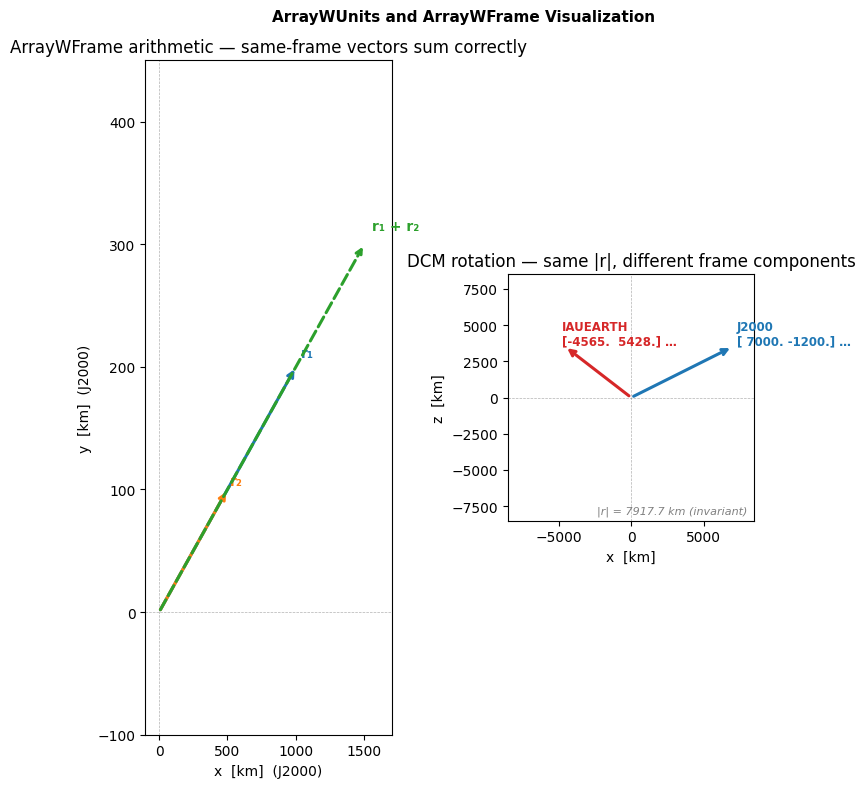

In [15]:
supp.supp_plotting.plot_awu_awf_visuals(R)